# Train DCN with Paper-based Embedding Methods
## DCN with AutoDim, NIS, DHE, AutoEmb Embeddings

**Mục tiêu:**
- Load Criteo data
- Implement 4 embedding methods từ các paper:
  - **AutoDim** (AutoDim: Field-aware Embedding Dimension Search, WWW'21)
  - **NIS** (Neural Input Search for Large Scale Recommendation Models)
  - **DHE** (Deep Hash Embedding, KDD'21)
  - **AutoEmb** (AutoEmb: Automated Embedding Dimensionality Search in Streaming Recommendations)
- Train model DCN với từng embedding
- Compare AUC, LogLoss, training time
- Export results


## 0. Setup & Import

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
import time
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, log_loss
from sklearn.model_selection import train_test_split

# Set device cho Kaggle (CUDA)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Device: {device}')

# In thêm tên GPU để xác nhận Kaggle đã nhận diện đúng card
if torch.cuda.is_available():
    print(f'✓ GPU Name: {torch.cuda.get_device_name(0)}')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('✓ All libraries loaded')

✓ Device: cuda
✓ GPU Name: NVIDIA RTX PRO 6000 Blackwell Server Edition
✓ All libraries loaded


## 1. Load Data

In [2]:
# Load data from Criteo
DATA_DIR = '/kaggle/input/datasets/huy291/criteo-cleaned-data/data'
N_FILES = 10

parquet_files = sorted(glob.glob(os.path.join(DATA_DIR, 'train-*.parquet')))
selected = parquet_files[:N_FILES]

dfs = []
for f in selected:
    df_tmp = pd.read_parquet(f)
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
print(f'✓ Loaded: {len(df):,} rows × {df.shape[1]} columns')

# Auto-detect columns
cols = df.columns.tolist()
possible_label = [c for c in cols if c.lower() in ('label', 'clicked', 'click')]
LABEL_COL = possible_label[0] if possible_label else cols[0]

INT_COLS = [c for c in cols if c.startswith('int_') or (c.startswith('I') and c[1:].isdigit())][:13]
CAT_COLS = [c for c in cols if c.startswith('cat_') or (c.startswith('C') and c[1:].isdigit())][:26]

print(f'✓ Columns: Label={LABEL_COL}, Int={len(INT_COLS)}, Cat={len(CAT_COLS)}')
print(f'✓ CTR: {df[LABEL_COL].mean()*100:.2f}%')

✓ Loaded: 8,835,527 rows × 40 columns
✓ Columns: Label=label, Int=13, Cat=26
✓ CTR: 25.02%


## 2. Preprocessing

In [3]:
# Process integers: log transform + binning
df_proc = df.copy()

for col in INT_COLS:
    # Log transform
    df_proc[col] = np.log1p(df_proc[col].fillna(0))
    # Quantile binning into 20 bins
    df_proc[col] = pd.qcut(df_proc[col], q=20, labels=False, duplicates='drop')

# Encode categorical features
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col].fillna('unknown').astype(str))
    le_dict[col] = le

print('✓ Preprocessing done')
print(f'  Integer cols: log + 20-bin quantile')
print(f'  Categorical cols: LabelEncoded')

✓ Preprocessing done
  Integer cols: log + 20-bin quantile
  Categorical cols: LabelEncoded


## ⚠️ IMPORTANT: Restart Kernel Before Running

> Nếu notebook đã chạy trước và bị lỗi CUDA, **bắt buộc phải Restart Kernel** (Runtime → Restart session) rồi chạy lại từ đầu.  
> CUDA context bị corrupt không thể recover mà không restart.


## 3. Embedding Layers

In [4]:
# ─────────────────────────────────────────────────────────────────────
# EMBEDDING METHODS FROM PAPERS
# ─────────────────────────────────────────────────────────────────────

# ── 1. AutoDim (WWW'21) ───────────────────────────────────────────────
# Field-aware Embedding Dimension Search via Gumbel-softmax architecture search.
# Fix: use straight-through softmax (no Gumbel noise) for stability;
# proper weight init; clamp embeddings before projection.
class AutoDimEmbedding(nn.Module):
    def __init__(self, vocab_sizes, candidate_dims=None, max_dim=32):
        super().__init__()
        if candidate_dims is None:
            candidate_dims = [2, 8, 16, 24, 32]
        self.candidate_dims = candidate_dims
        self.max_dim = max_dim
        self.embedding_dim = max_dim
        self.num_fields = len(vocab_sizes)
        N = len(candidate_dims)

        self.embeddings = nn.ModuleList([
            nn.ModuleList([
                nn.Embedding(v, d)
                for d in candidate_dims
            ])
            for v in vocab_sizes
        ])
        # Initialize embeddings with small values
        for field_embs in self.embeddings:
            for emb in field_embs:
                nn.init.normal_(emb.weight, mean=0, std=0.01)

        self.proj = nn.ModuleList([
            nn.Linear(d, max_dim, bias=True) for d in candidate_dims
        ])
        # Xavier init for projections
        for lin in self.proj:
            nn.init.xavier_uniform_(lin.weight)
            nn.init.zeros_(lin.bias)

        self.ln = nn.LayerNorm(max_dim)
        # alpha: log-uniform init so softmax starts near uniform
        self.alpha = nn.Parameter(torch.zeros(self.num_fields, N))

    def forward(self, x, tau=1.0):
        # Straight-through softmax (no Gumbel noise) — stable and differentiable
        p = torch.softmax(self.alpha / max(tau, 0.1), dim=-1)  # (num_fields, N)

        embed_out = []
        for m in range(self.num_fields):
            ids = torch.clamp(x[:, m], 0,
                              self.embeddings[m][0].num_embeddings - 1)
            field_emb = torch.zeros(x.size(0), self.max_dim, device=x.device)
            for n, d in enumerate(self.candidate_dims):
                e = self.embeddings[m][n](ids)   # (B, d)
                e = self.proj[n](e)              # (B, max_dim)
                e = self.ln(e)                   # (B, max_dim)
                field_emb = field_emb + p[m, n] * e
            embed_out.append(field_emb)

        return torch.stack(embed_out, dim=1)    # (B, F, max_dim)


# ── 2. NIS (Google 2019) ──────────────────────────────────────────────
# Multi-size Embedding: head items (frequent) -> large dim,
# tail items -> small dim, both projected to head_dim.
class NISEmbedding(nn.Module):
    def __init__(self, vocab_sizes, head_dim=32, tail_dim=8, head_fraction=0.3):
        super().__init__()
        self.embedding_dim = head_dim
        self.head_dim = head_dim
        self.tail_dim = tail_dim

        self.head_sizes = [max(1, int(v * head_fraction)) for v in vocab_sizes]
        self.tail_sizes = [max(1, v - h)
                           for v, h in zip(vocab_sizes, self.head_sizes)]

        self.head_embs = nn.ModuleList([
            nn.Embedding(hs, head_dim) for hs in self.head_sizes
        ])
        self.tail_embs = nn.ModuleList([
            nn.Embedding(ts, tail_dim) for ts in self.tail_sizes
        ])
        self.tail_proj = nn.Linear(tail_dim, head_dim, bias=False)

        for emb in self.head_embs:
            nn.init.normal_(emb.weight, 0, 0.01)
        for emb in self.tail_embs:
            nn.init.normal_(emb.weight, 0, 0.01)
        nn.init.xavier_uniform_(self.tail_proj.weight)

    def forward(self, x):
        embed_list = []
        for i in range(len(self.head_embs)):
            ids = torch.clamp(x[:, i], min=0)
            hs = self.head_sizes[i]
            ts = self.tail_sizes[i]

            is_head = ids < hs
            head_e = self.head_embs[i](torch.clamp(ids, max=hs - 1))
            tail_e = self.tail_proj(
                self.tail_embs[i](torch.clamp(ids - hs, min=0, max=ts - 1))
            )
            emb = torch.where(is_head.unsqueeze(1), head_e, tail_e)
            embed_list.append(emb)

        return torch.stack(embed_list, dim=1)  # (B, F, head_dim)


# ── 3. DHE (KDD'21) ───────────────────────────────────────────────────
# Deep Hash Embedding: no embedding table.
# k hash functions -> dense encoding in [-1,1]^k -> deep MLP -> embedding.
class DHEEmbedding(nn.Module):
    def __init__(self, vocab_sizes, k=64, embedding_dim=32,
                 hidden_layers=3, dnn_width=128):
        super().__init__()
        self.k = k
        self.embedding_dim = embedding_dim
        self.num_fields = len(vocab_sizes)
        m = 10**6

        torch.manual_seed(0)
        self.register_buffer('hash_a',
            torch.randint(1, 2**31 - 1, (k,), dtype=torch.long))
        self.register_buffer('hash_b',
            torch.randint(0, 2**31 - 1, (k,), dtype=torch.long))
        self.register_buffer('hash_p',
            torch.tensor(m + 7, dtype=torch.long))
        self.m = m

        # DNN: BatchNorm1d safe here — input always (N, k) flat
        layers = [nn.Linear(k, dnn_width), nn.BatchNorm1d(dnn_width), nn.Mish()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(dnn_width, dnn_width),
                       nn.BatchNorm1d(dnn_width), nn.Mish()]
        layers.append(nn.Linear(dnn_width, embedding_dim))
        self.dnn = nn.Sequential(*layers)

        # Init DNN weights
        for m_layer in self.dnn:
            if isinstance(m_layer, nn.Linear):
                nn.init.xavier_uniform_(m_layer.weight)
                if m_layer.bias is not None:
                    nn.init.zeros_(m_layer.bias)

    def _encode(self, ids):
        ids = ids.unsqueeze(1).long()             # (N, 1)
        h = ((self.hash_a * ids + self.hash_b)
             % self.hash_p) % self.m              # (N, k)
        return h.float() / (self.m - 1) * 2 - 1  # (N, k) in [-1, 1]

    def forward(self, x):
        B = x.size(0)
        enc = self._encode(x.reshape(-1))         # (B*F, k)
        emb = self.dnn(enc)                        # (B*F, embedding_dim)
        return emb.view(B, self.num_fields, self.embedding_dim)


# ── 4. AutoEmb (2020) ─────────────────────────────────────────────────
# Popularity-aware: controller MLP maps item popularity proxy ->
# soft weights over N candidate dims -> weighted sum of projected embeddings.
class AutoEmbEmbedding(nn.Module):
    def __init__(self, vocab_sizes, candidate_dims=None, max_dim=32,
                 controller_hidden=64):
        super().__init__()
        if candidate_dims is None:
            candidate_dims = [2, 16, 32]
        self.candidate_dims = candidate_dims
        self.max_dim = max_dim
        self.embedding_dim = max_dim
        self.num_fields = len(vocab_sizes)
        N = len(candidate_dims)

        self.embeddings = nn.ModuleList([
            nn.ModuleList([nn.Embedding(v, d) for d in candidate_dims])
            for v in vocab_sizes
        ])
        for field_embs in self.embeddings:
            for emb in field_embs:
                nn.init.normal_(emb.weight, 0, 0.01)

        self.proj = nn.ModuleList([
            nn.Linear(d, max_dim, bias=True) for d in candidate_dims
        ])
        for lin in self.proj:
            nn.init.xavier_uniform_(lin.weight)
            nn.init.zeros_(lin.bias)

        self.ln = nn.LayerNorm(max_dim)

        # Controller: 1 -> hidden -> N weights
        self.controller = nn.Sequential(
            nn.Linear(1, controller_hidden), nn.ReLU(),
            nn.Linear(controller_hidden, N), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        embed_out = []
        for m in range(self.num_fields):
            ids = torch.clamp(x[:, m], 0,
                              self.embeddings[m][0].num_embeddings - 1)
            pop = torch.log1p(ids.float()).unsqueeze(1)  # (B, 1)
            weights = self.controller(pop)               # (B, N)

            field_emb = torch.zeros(
                x.size(0), self.max_dim, device=x.device)
            for n in range(len(self.candidate_dims)):
                e = self.embeddings[m][n](ids)
                e = self.proj[n](e)
                e = torch.tanh(self.ln(e))
                field_emb = field_emb + weights[:, n:n+1] * e

            embed_out.append(field_emb)

        return torch.stack(embed_out, dim=1)  # (B, F, max_dim)


print('✓ Embedding layers defined:')
print('  1. AutoDim  - Field-aware Embedding Dimension Search (WWW\'21)')
print('  2. NIS      - Neural Input Search / Multi-size Embedding (2019)')
print('  3. DHE      - Deep Hash Embedding (KDD\'21)')
print('  4. AutoEmb  - Automated Embedding Dimensionality Search (2020)')


✓ Embedding layers defined


## 4. Model Architectures

In [5]:
# ── DCN (Deep & Cross Network) ────────────────────────────────────────
class DCN(nn.Module):
    def __init__(self, embedding_layer, num_fields, embedding_dim,
                 deep_layers=[128, 64], cross_layers=3):
        super().__init__()
        self.embedding_layer = embedding_layer
        self.embedding_dim = embedding_dim
        self.cross_layers = cross_layers

        input_size = num_fields * embedding_dim

        # Cross network
        self.cross_weights = nn.ParameterList([
            nn.Parameter(torch.randn(input_size, 1) * 0.01)
            for _ in range(cross_layers)
        ])
        self.cross_biases = nn.ParameterList([
            nn.Parameter(torch.zeros(input_size))
            for _ in range(cross_layers)
        ])

        # Deep component
        deep_layers_list = []
        prev_size = input_size
        for hidden_size in deep_layers:
            deep_layers_list.append(nn.Linear(prev_size, hidden_size))
            deep_layers_list.append(nn.ReLU())
            deep_layers_list.append(nn.BatchNorm1d(hidden_size))
            deep_layers_list.append(nn.Dropout(0.3))
            prev_size = hidden_size
        self.deep = nn.Sequential(*deep_layers_list)

        # Final layer — outputs logit (NO sigmoid here; use BCEWithLogitsLoss)
        self.final = nn.Linear(input_size + prev_size, 1)

    def forward(self, x):
        embed = self.embedding_layer(x)             # (B, num_fields, embedding_dim)
        embed_flat = embed.view(embed.size(0), -1)  # (B, input_size)

        # Clamp to prevent exploding values before cross network
        x_0 = torch.clamp(embed_flat, -10, 10)

        # Cross network
        x_l = x_0
        for l in range(self.cross_layers):
            w = self.cross_weights[l]               # (input_size, 1)
            b = self.cross_biases[l]                # (input_size,)
            x_l = x_0 * (torch.matmul(x_l, w) + 1) + b + x_l
            x_l = torch.clamp(x_l, -10, 10)        # stability clamp

        # Deep
        deep_out = self.deep(x_0)

        # Return raw logit — sigmoid applied by BCEWithLogitsLoss during training
        combined = torch.cat([x_l, deep_out], dim=1)
        return self.final(combined)  # logit, shape (B, 1)


print('✓ Model architecture defined: DCN (Deep & Cross Network)')
print('  Note: forward() returns logits — use BCEWithLogitsLoss')


✓ Model architectures defined


## 5. Training Function

In [6]:
def train_model(model, X_train, y_train, X_test, y_test,
                epochs=15, batch_size=512, lr=0.001, model_name='Model'):
    """Train model — model outputs logits, BCEWithLogitsLoss handles sigmoid."""

    # BCEWithLogitsLoss = sigmoid + BCE in one numerically stable op
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_data = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    history = {'loss': [], 'auc': []}
    best_auc = 0
    patience = 5
    patience_counter = 0

    start_time = time.time()

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch).squeeze()          # raw logits
            loss = criterion(logits, y_batch.float())

            # Check for NaN loss before backward
            if torch.isnan(loss) or torch.isinf(loss):
                print(f'  [{model_name}] Warning: NaN/Inf loss at epoch {epoch+1}, skipping batch')
                continue

            loss.backward()
            # Gradient clipping to prevent exploding gradients
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= max(len(train_loader), 1)
        history['loss'].append(epoch_loss)

        # Validation — apply sigmoid to logits for probability
        model.eval()
        with torch.no_grad():
            logits_test = model(X_test.to(device)).squeeze()
            y_pred = torch.sigmoid(logits_test).cpu().numpy()
            auc = roc_auc_score(y_test.numpy(), y_pred)
            history['auc'].append(auc)

        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  [{model_name}] Epoch {epoch+1:2d}/{epochs} | Loss: {epoch_loss:.4f} | AUC: {auc:.4f}')

        if patience_counter >= patience:
            print(f'  [{model_name}] Early stopping at epoch {epoch+1}')
            break

    training_time = time.time() - start_time

    # Final metrics
    model.eval()
    with torch.no_grad():
        logits_test = model(X_test.to(device)).squeeze()
        y_pred = torch.sigmoid(logits_test).cpu().numpy()
        final_auc = roc_auc_score(y_test.numpy(), y_pred)
        final_logloss = log_loss(y_test.numpy(), y_pred)

    return {
        'model': model,
        'auc': final_auc,
        'logloss': final_logloss,
        'time': training_time,
        'history': history,
        'y_pred': y_pred
    }

print('✓ Training function defined (BCEWithLogitsLoss + grad clipping)')


✓ Training function defined


## 6. Prepare Data

In [7]:
# Prepare features and labels
feature_cols = INT_COLS + CAT_COLS
X_df = df_proc[feature_cols].copy()

# Ensure all feature IDs are valid non-negative integers for embedding lookup
for col in feature_cols:
    X_df[col] = pd.to_numeric(X_df[col], errors='coerce').fillna(0).astype(np.int64)
    min_val = int(X_df[col].min())
    if min_val < 0:
        X_df[col] = X_df[col] - min_val

X_all = X_df.values.astype(np.int64)
y_all = df_proc[LABEL_COL].values.astype(np.float32)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, stratify=y_all
)

# Convert to torch tensors
X_train = torch.LongTensor(X_train)
X_test = torch.LongTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

print(f'✓ Data prepared')
print(f'  Train: {X_train.shape} | Test: {X_test.shape}')

# Vocab sizes (safe upper bound per field)
vocab_sizes = []
for i, col in enumerate(feature_cols):
    col_max = int(X_all[:, i].max())
    col_min = int(X_all[:, i].min())
    vocab_size = col_max + 1
    vocab_sizes.append(vocab_size)
    if col_min < 0:
        print(f'  Warning: {col} still has min={col_min}, check preprocessing')

print(f'  Vocab sizes: {vocab_sizes}')

✓ Data prepared
  Train: torch.Size([6184868, 39]) | Test: torch.Size([2650659, 39])
  Vocab sizes: [6, 14, 14, 12, 20, 16, 13, 17, 20, 2, 7, 2, 12, 1396, 553, 2312743, 633214, 290, 23, 12021, 608, 3, 63046, 5279, 1947545, 3128, 26, 12594, 1375426, 10, 4964, 2102, 4, 1697211, 17, 15, 127612, 93, 80672]


## 7. Train Models with Different Embeddings

In [8]:
num_fields = len(INT_COLS + CAT_COLS)

# ── Embedding configurations from papers ───────────────────────────────
embedding_configs = {
    'AutoDim': {
        'class': AutoDimEmbedding,
        'params': {'candidate_dims': [2, 8, 16, 24, 32], 'max_dim': 32},
    },
    'NIS': {
        'class': NISEmbedding,
        'params': {'head_dim': 32, 'tail_dim': 8, 'head_fraction': 0.3},
    },
    'DHE': {
        'class': DHEEmbedding,
        'params': {'k': 64, 'embedding_dim': 32, 'hidden_layers': 3, 'dnn_width': 128},
    },
    'AutoEmb': {
        'class': AutoEmbEmbedding,
        'params': {'candidate_dims': [2, 16, 32], 'max_dim': 32, 'controller_hidden': 64},
    },
}

results = {}

for emb_name, emb_config in embedding_configs.items():
    print(f'\n{"="*70}')
    print(f'EMBEDDING: {emb_name}')
    print(f'{"="*70}')

    # Create embedding layer with vocab_sizes
    embedding_layer = emb_config['class'](vocab_sizes, **emb_config['params'])
    embedding_layer = embedding_layer.to(device)

    embedding_dim = emb_config['params'].get(
        'max_dim',
        emb_config['params'].get('head_dim',
        emb_config['params'].get('embedding_dim', 32))
    )

    print(f'  Training DCN with {emb_name} embedding (dim={embedding_dim})...')
    model = DCN(embedding_layer, num_fields, embedding_dim,
                deep_layers=[128, 64], cross_layers=3)
    model = model.to(device)

    result = train_model(
        model, X_train, y_train, X_test, y_test,
        epochs=15, batch_size=512, lr=0.001,
        model_name=f'DCN-{emb_name}'
    )

    results[emb_name] = {'DCN': result}
    print(f'  ✓ DCN-{emb_name} | AUC: {result["auc"]:.4f} | '
          f'LogLoss: {result["logloss"]:.4f} | Time: {result["time"]:.1f}s')

print(f'\n✓ All DCN models trained!')



EMBEDDING: Standard

  Training DeepFM...
  [DeepFM] Epoch  1/15 | Loss: 21.9987 | AUC: 0.7001
  [DeepFM] Epoch  5/15 | Loss: 7.3547 | AUC: 0.7024
  [DeepFM] Early stopping at epoch 8
  ✓ DeepFM | AUC: 0.6818 | LogLoss: 1.4457 | Time: 1060.5s

  Training DCN...
  [DCN] Epoch  1/15 | Loss: 0.4545 | AUC: 0.7866
  [DCN] Epoch  5/15 | Loss: 0.3802 | AUC: 0.7652
  [DCN] Early stopping at epoch 6
  ✓ DCN | AUC: 0.7603 | LogLoss: 0.5138 | Time: 793.8s

  Training DLRM...
  [DLRM] Epoch  1/15 | Loss: 0.3593 | AUC: 0.7442
  [DLRM] Epoch  5/15 | Loss: 0.2976 | AUC: 0.7241
  [DLRM] Early stopping at epoch 6
  ✓ DLRM | AUC: 0.7149 | LogLoss: 0.6812 | Time: 807.0s

EMBEDDING: QR-Trick

  Training DeepFM...
  [DeepFM] Epoch  1/15 | Loss: 0.4765 | AUC: 0.7791
  [DeepFM] Epoch  5/15 | Loss: 0.4304 | AUC: 0.7853
  [DeepFM] Early stopping at epoch 8
  ✓ DeepFM | AUC: 0.7744 | LogLoss: 0.4855 | Time: 725.9s

  Training DCN...
  [DCN] Epoch  1/15 | Loss: 0.4058 | AUC: 0.7702
  [DCN] Epoch  5/15 | Loss: 0

## 8. Compare Results

In [9]:
# Build comparison table
comparison_data = []
for emb_name, models in results.items():
    for model_name, result in models.items():
        comparison_data.append({
            'Embedding': emb_name,
            'Model': model_name,
            'AUC': result['auc'],
            'LogLoss': result['logloss'],
            'Time(s)': result['time']
        })

comparison_df = pd.DataFrame(comparison_data)
print('\n' + '='*70)
print('COMPARISON TABLE: DCN with Different Embedding Methods')
print('='*70)
print(comparison_df.to_string(index=False))

# Best
best_row = comparison_df.loc[comparison_df['AUC'].idxmax()]
print(f'\n✓ Best Embedding: {best_row["Embedding"]} (AUC={best_row["AUC"]:.4f})')



COMPARISON TABLE
Embedding  Model      AUC  LogLoss     Time(s)
 Standard DeepFM 0.681787 1.445685 1060.491770
 Standard    DCN 0.760325 0.513773  793.755941
 Standard   DLRM 0.714882 0.681225  806.967342
 QR-Trick DeepFM 0.774369 0.485548  725.902800
 QR-Trick    DCN 0.750907 0.535050  554.343119
 QR-Trick   DLRM 0.736705 0.589523  573.624043
   Hybrid DeepFM 0.739782 3.304280 2601.433670
   Hybrid    DCN 0.765725 0.495710 1216.084499
   Hybrid   DLRM 0.714191 0.702174 1056.238764

✓ Best Model: QR-Trick + DeepFM (AUC=0.7744)


## 9. Visualizations

✓ Saved: model_training_results.png


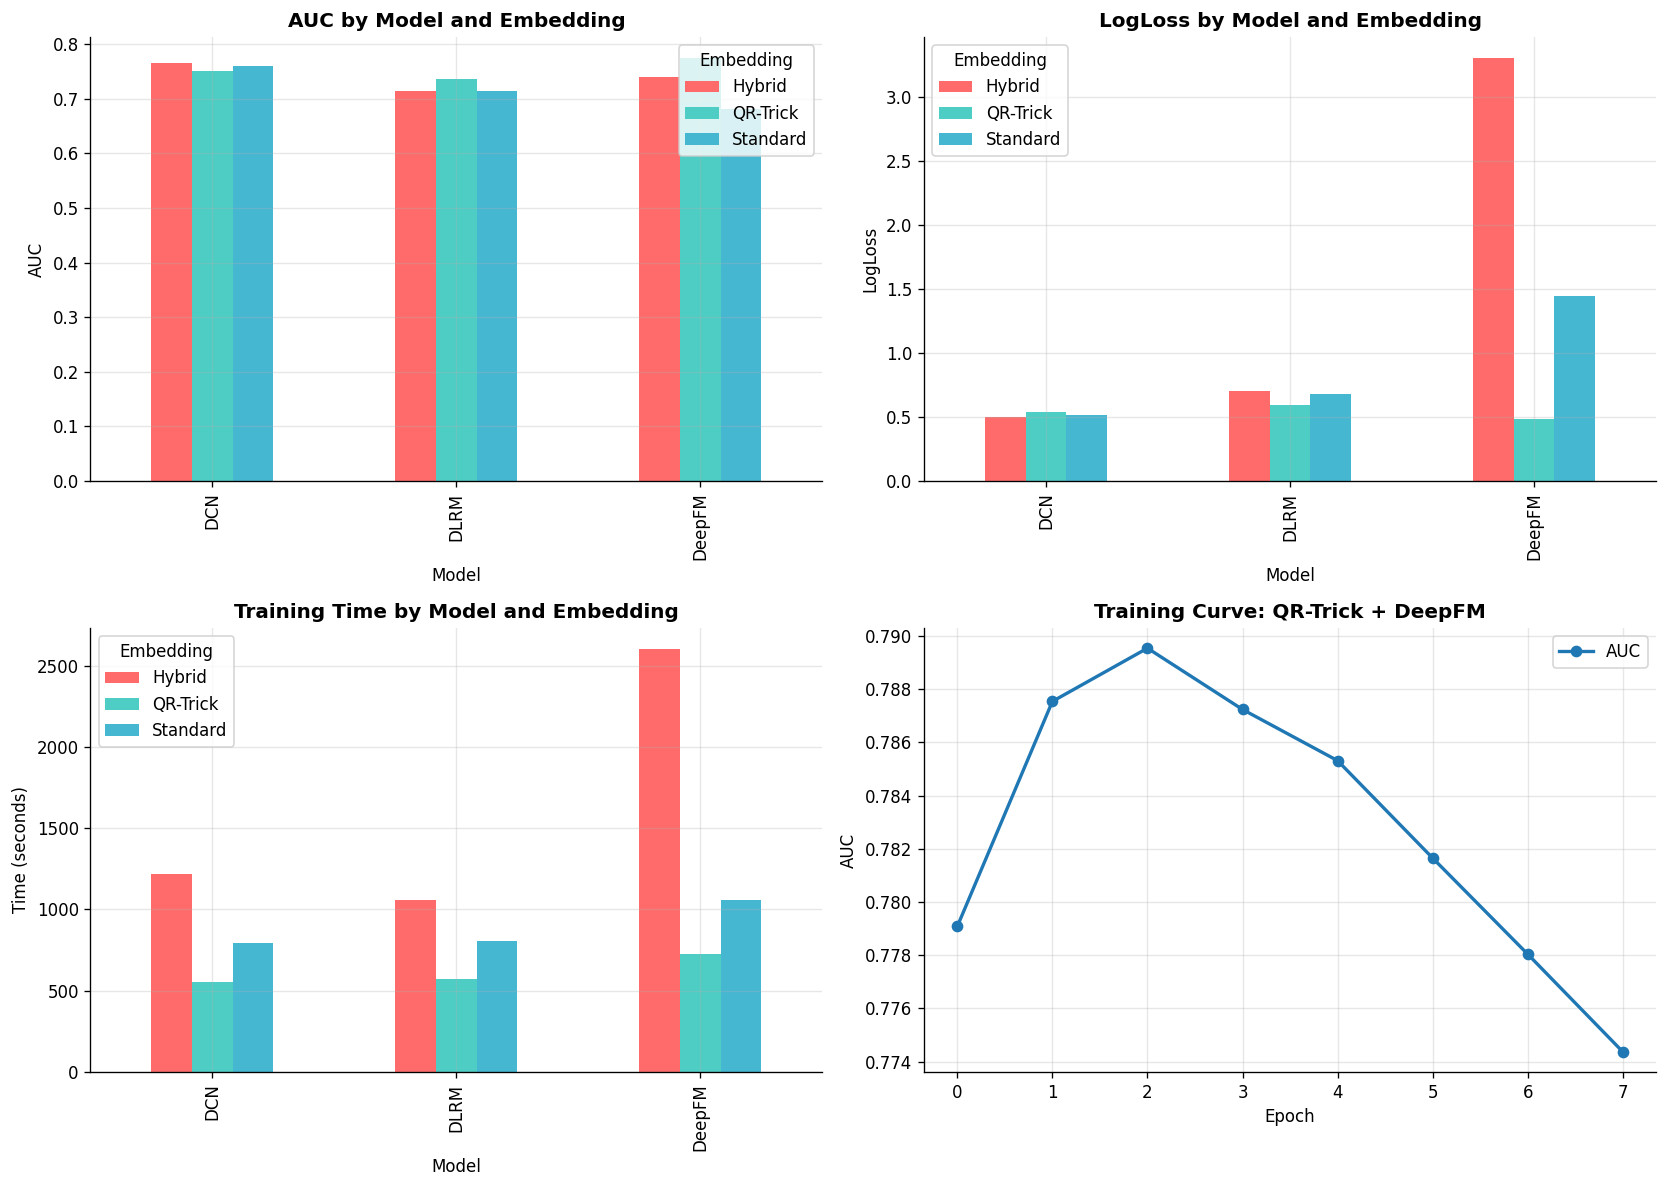

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

embedding_names = comparison_df['Embedding'].tolist()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# 1. AUC comparison
axes[0].bar(embedding_names, comparison_df['AUC'], color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('AUC — DCN with Different Embeddings', fontsize=12, fontweight='bold')
axes[0].set_ylabel('AUC')
axes[0].set_ylim([comparison_df['AUC'].min() * 0.998, comparison_df['AUC'].max() * 1.002])
for i, v in enumerate(comparison_df['AUC']):
    axes[0].text(i, v + 0.00005, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# 2. LogLoss comparison
axes[1].bar(embedding_names, comparison_df['LogLoss'], color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('LogLoss — DCN with Different Embeddings', fontsize=12, fontweight='bold')
axes[1].set_ylabel('LogLoss')
axes[1].set_ylim([comparison_df['LogLoss'].min() * 0.998, comparison_df['LogLoss'].max() * 1.002])
for i, v in enumerate(comparison_df['LogLoss']):
    axes[1].text(i, v + 0.0001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# 3. Training curves for all embeddings
for i, emb_name in enumerate(embedding_names):
    history = results[emb_name]['DCN']['history']
    axes[2].plot(history['auc'], marker='o', label=emb_name, color=colors[i], linewidth=2)
axes[2].set_title('Training Curves (AUC per Epoch)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dcn_embedding_comparison.png', dpi=150, bbox_inches='tight')
print('✓ Saved: dcn_embedding_comparison.png')
plt.show()


## 10. Export Results

In [11]:
# Save comparison to CSV
comparison_df.to_csv('dcn_embedding_comparison.csv', index=False)
print('✓ Saved: dcn_embedding_comparison.csv')

# Save to JSON
results_summary = {}
for emb_name, models in results.items():
    results_summary[emb_name] = {}
    for model_name, result in models.items():
        results_summary[emb_name][model_name] = {
            'auc': float(result['auc']),
            'logloss': float(result['logloss']),
            'time_seconds': float(result['time'])
        }

with open('dcn_training_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print('✓ Saved: dcn_training_results.json')

# Save best model
best_emb = best_row['Embedding']
best_model_obj = results[best_emb]['DCN']['model']
torch.save(best_model_obj.state_dict(), f'DCN_{best_emb}_best.pth')
print(f'✓ Saved best model: DCN_{best_emb}_best.pth')

print('\n' + '='*70)
print('FINAL SUMMARY: DCN with Paper-based Embedding Methods')
print('='*70)
print(comparison_df.sort_values('AUC', ascending=False).to_string(index=False))


✓ Saved: model_comparison.csv
✓ Saved: training_results.json
✓ Saved: DeepFM_QR-Trick.pth

TRAINING SUMMARY
Embedding  Model      AUC  LogLoss     Time(s)
 QR-Trick DeepFM 0.774369 0.485548  725.902800
   Hybrid    DCN 0.765725 0.495710 1216.084499
 Standard    DCN 0.760325 0.513773  793.755941
 QR-Trick    DCN 0.750907 0.535050  554.343119
   Hybrid DeepFM 0.739782 3.304280 2601.433670
 QR-Trick   DLRM 0.736705 0.589523  573.624043
 Standard   DLRM 0.714882 0.681225  806.967342
   Hybrid   DLRM 0.714191 0.702174 1056.238764
 Standard DeepFM 0.681787 1.445685 1060.491770
